## Import libraries

In [118]:
import numpy as np
import matplotlib.pyplot as plt
import torch
from tqdm import tqdm


import sys, os
sys.path.append(os.path.join(os.getcwd(), "../ml-force"))


from ml_force import MorrisLecar, MorrisLecarCurrent
from ml_force.utils import minmax_transform, z_transform
from ml_force.supervisors import LorenzAttractor
from ml_force.plots import plot_model
from scipy.signal import find_peaks

## Preparations for Lorenz Attractor

In [119]:
seed = 1
np.random.seed(seed)
torch.cuda.manual_seed(seed)
torch.random.manual_seed(seed)

T = 20000
dt = 5e-2
t = np.arange(0, T, dt)
nt = t.size
# x = VanDerPol(T, dt, mu=1, tau=.02).generate(transient_time=500.0)
x = LorenzAttractor(T, dt, tau=.01).generate(transient_time=1000.0)

x = x.T
# sup = minmax_transform(x, zero_mean=True)
sup = z_transform(x)
print(sup.shape)

(400000, 3)


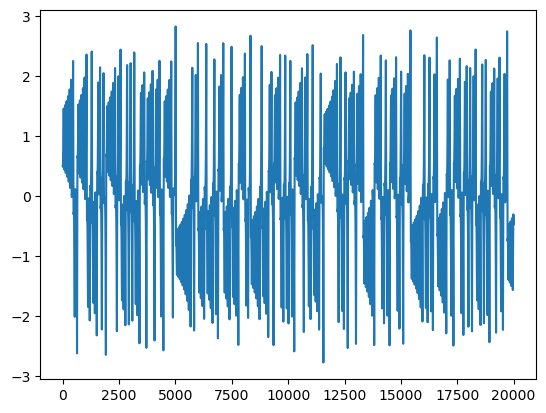

In [120]:
plt.plot(t, sup[:, 1])
plt.show()

# ML Conductance-based Model

In [263]:
NE = 2500
NI = 2500
N = NI + NE

# input current for I and E neurons
Ie = 60     # pA
Ii = 80     # pA
current = np.ones((N, 1))
middle = N // 2
current[:middle] *= Ie  # NE bias
current[middle:] *= Ii  # NI bias
# current = np.random.rand(N, 1) * Ie

Q = 150
lamda = 1.
gbar = 15

In [264]:
device = torch.device("cuda" if torch.cuda.is_available() else 'cpu')
print(f"Using Device <{device}> for PyTorch computations...\n")
torch.cuda.random.manual_seed(seed)

try:
    ml = MorrisLecarCurrent(supervisor=sup, BIAS=current, T=T, dt=dt, 
                                p_sparsity=.01,
                                N=N, Q=Q, gbar=gbar, l=lamda, device=device)
except Exception as e:
    print(e)
    print(torch.cuda.memory_summary(device=device))

Using Device <cuda> for PyTorch computations...



In [265]:
# colors = plt.pcolormesh(ml.w.cpu().numpy(), cmap='viridis')
# plt.colorbar(colors)
# plt.show()

print(f"Mean: {ml.w.type(dtype=torch.float64).mean().item()}, \nSTD: {ml.w.type(dtype=torch.float64).std().item()}")
print(f"Max: {ml.w.type(dtype=torch.float64).max().item()}, \nMin: {ml.w.type(dtype=torch.float64).min().item()}")

Mean: -3.590855240413912e-05, 
STD: 0.1414378682899079
Max: 0.8641430735588074, 
Min: -0.7442820072174072


In [266]:
# RLS params
# rls_stop = round(T * .6)
rls_start = 500
test_time = T * .4    # ms
rls_stop = T - test_time
rls_step = 20

memory_length = 5000    # ms
rls_gap = rls_step * dt
memory_coeff = memory_length / rls_gap
ff_coeff = 1 - 1 / memory_coeff

ff_coeff

0.9998

In [267]:
save_path = os.path.join(os.getcwd(), "results", f"Q_{Q}_gbar_{gbar}_l_{lamda}")
os.makedirs(save_path, exist_ok=True)

def save_tensor(tensor, name):
    file_name = name + ".pt"
    torch.save(tensor, os.path.join(save_path, file_name))
    print(f"Saved {file_name} in {save_path}")

In [ ]:
duration = 500
nt_transient = int(duration // dt)

n_neurons = 10
neurons = np.random.choice(N, n_neurons, replace=False)
print(neurons)

print(f"Transient Period: {duration} ms")
for i in tqdm(range(nt_transient)):
    ml.euler_step()

nt_train = int((T-test_time) // dt)
s_rec_train = torch.zeros((nt_train, n_neurons), device=device, dtype=torch.float32)
v_rec_train = torch.zeros((nt_train, n_neurons), device=device, dtype=torch.float32)
n_rec_train = torch.zeros((nt_train, n_neurons), device=device, dtype=torch.float32)
xhat_rec_train = torch.zeros((nt_train, sup.shape[1]), device=device, dtype=torch.float32)
dec_rec_train = torch.zeros((nt_train, n_neurons, sup.shape[1]), device=device, dtype=torch.float32)

print(f"Trining Period: {T-test_time} ms")
for i in tqdm(range(nt_train)):
    ml.euler_step(closed_loop=True)
    s_rec_train[i] = ml.s[neurons].ravel()
    v_rec_train[i] = ml.v[neurons].ravel()
    n_rec_train[i] = ml.n[neurons].ravel()
    xhat_rec_train[i] = ml.x_hat.ravel()
    dec_rec_train[i] = ml.dec[neurons]

    if i <= int(rls_stop // dt) and i % rls_step == 0:
        # ml.rls_ff(i, ff_coeff=ff_coeff)
        ml.rls(i)

[4449 3289 4177  801 3825  530 4743 4109 3326  485]
Transient Period: 500 ms


 82%|████████▏ | 8153/9999 [00:12<00:02, 640.84it/s]

In [224]:
save_tensor(ml.w, "weights")
save_tensor(s_rec_train, "s_rec_train")
save_tensor(v_rec_train, "v_rec_train")
save_tensor(n_rec_train, "n_rec_train")
save_tensor(xhat_rec_train, "xhat_rec_train")
save_tensor(dec_rec_train, "dec_rec_train")


Saved weights.pt in /home/ali/Code/research/ml_force_research/morris_lecar/results/Q_150_gbar_15_l_1.0
Saved s_rec_train.pt in /home/ali/Code/research/ml_force_research/morris_lecar/results/Q_150_gbar_15_l_1.0
Saved v_rec_train.pt in /home/ali/Code/research/ml_force_research/morris_lecar/results/Q_150_gbar_15_l_1.0
Saved n_rec_train.pt in /home/ali/Code/research/ml_force_research/morris_lecar/results/Q_150_gbar_15_l_1.0
Saved xhat_rec_train.pt in /home/ali/Code/research/ml_force_research/morris_lecar/results/Q_150_gbar_15_l_1.0
Saved dec_rec_train.pt in /home/ali/Code/research/ml_force_research/morris_lecar/results/Q_150_gbar_15_l_1.0


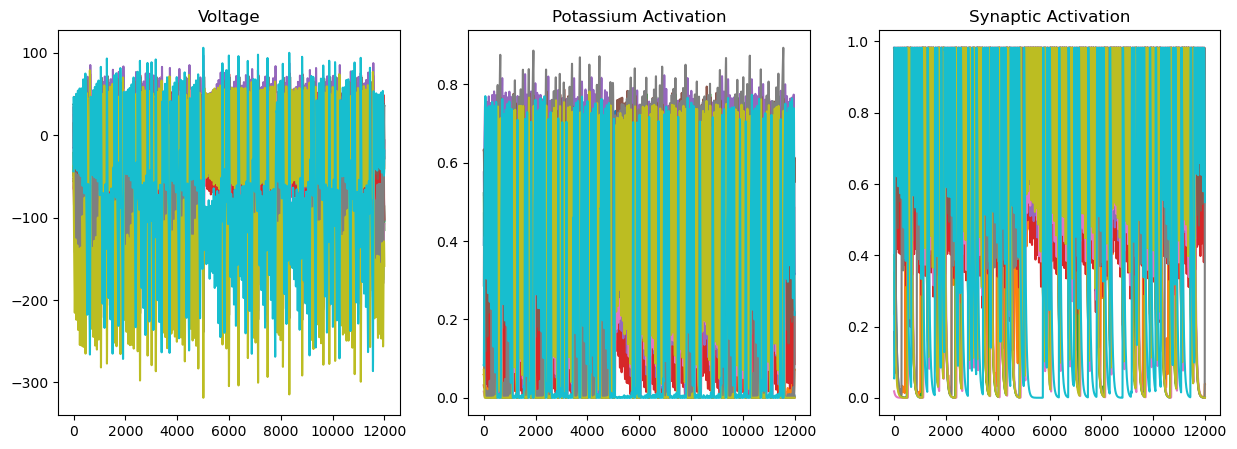

In [225]:
t_train = np.arange(nt_train) * dt

fig, ax = plt.subplots(1, 3, figsize=(15, 5), sharex=True)
ax[0].plot(t_train, v_rec_train.cpu().numpy())
ax[0].set_title('Voltage')
ax[1].plot(t_train, n_rec_train.cpu().numpy())
ax[1].set_title('Potassium Activation')
ax[2].plot(t_train, s_rec_train.cpu().numpy())
ax[2].set_title('Synaptic Activation')

plt.show()

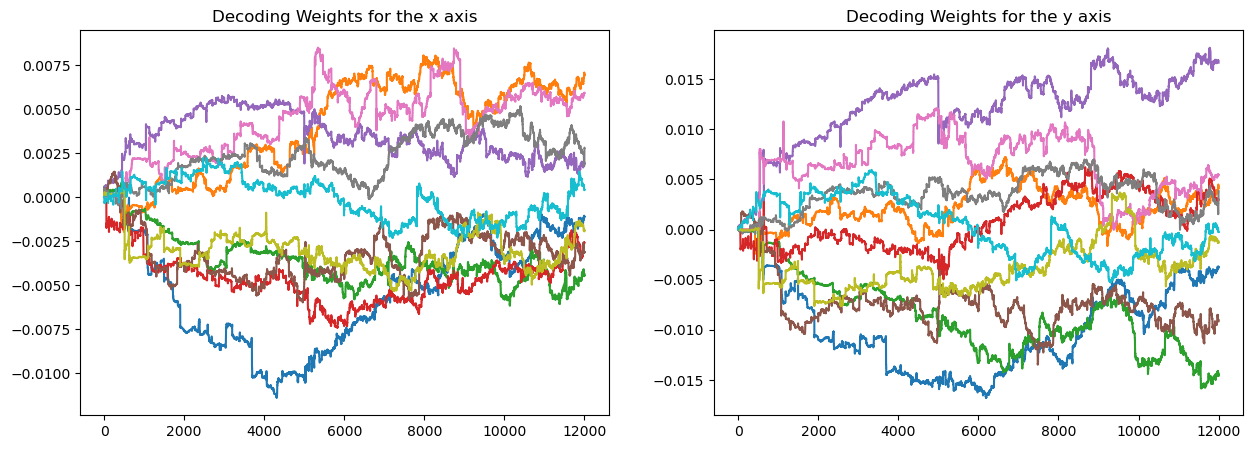

In [226]:
fig, ax = plt.subplots(1, 2, figsize=(15, 5), sharex=True)
ax[0].plot(t_train, dec_rec_train[:, :, 0].cpu().numpy())
ax[0].set_title('Decoding Weights for the x axis')
ax[1].plot(t_train, dec_rec_train[:, :, 1].cpu().numpy())
ax[1].set_title('Decoding Weights for the y axis')
plt.show()

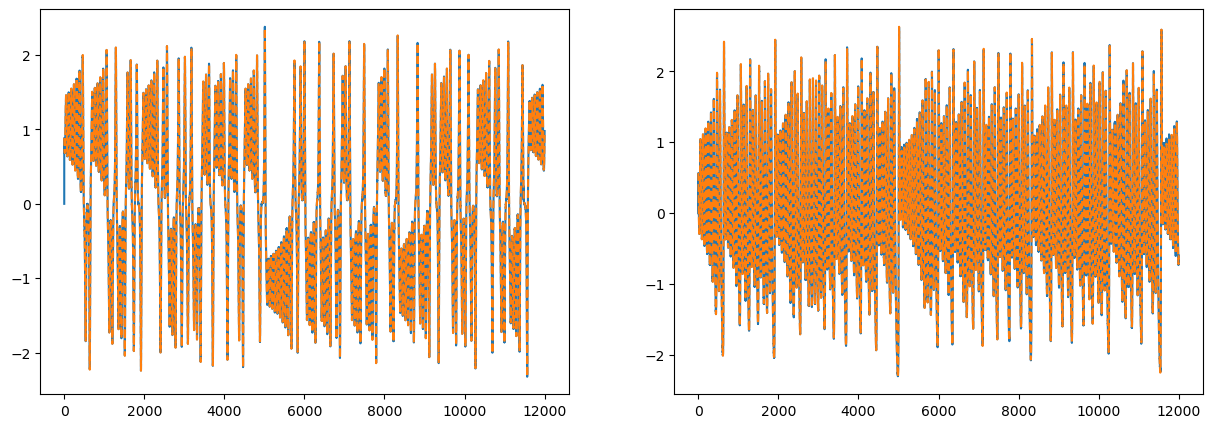

In [227]:
fig, ax = plt.subplots(1, 2, figsize=(15, 5), sharex=True)
ax[0].plot(t_train, xhat_rec_train[:, 0].cpu().numpy())
ax[0].plot(t_train, sup[:nt_train, 0], '--')
ax[1].plot(t_train, xhat_rec_train[:, 2].cpu().numpy())
ax[1].plot(t_train, sup[:nt_train, 2], '--')
plt.show()

In [228]:
nt_test = int(test_time // dt)
s_rec_test = torch.zeros((nt_test, n_neurons), device=device, dtype=torch.float32)
v_rec_test = torch.zeros((nt_test, n_neurons), device=device, dtype=torch.float32)
n_rec_test = torch.zeros((nt_test, n_neurons), device=device, dtype=torch.float32)
x_hat_rec = torch.zeros((nt_test, sup.shape[1]), device=device, dtype=torch.float32)

print(f"Testing Period: {test_time} ms")
for i in tqdm(range(nt_test)):
    ml.euler_step(closed_loop=True)
    s_rec_test[i] = ml.s[neurons].ravel()
    v_rec_test[i] = ml.v[neurons].ravel()
    n_rec_test[i] = ml.n[neurons].ravel()
    x_hat_rec[i] = ml.x_hat.ravel()

Testing Period: 8000.0 ms


100%|██████████| 159999/159999 [04:28<00:00, 596.65it/s]


In [229]:
save_tensor(s_rec_test, "s_rec_test")
save_tensor(v_rec_test, "v_rec_test")
save_tensor(n_rec_test, "n_rec_test")
save_tensor(x_hat_rec, "x_hat_rec")

Saved s_rec_test.pt in /home/ali/Code/research/ml_force_research/morris_lecar/results/Q_150_gbar_15_l_1.0
Saved v_rec_test.pt in /home/ali/Code/research/ml_force_research/morris_lecar/results/Q_150_gbar_15_l_1.0
Saved n_rec_test.pt in /home/ali/Code/research/ml_force_research/morris_lecar/results/Q_150_gbar_15_l_1.0
Saved x_hat_rec.pt in /home/ali/Code/research/ml_force_research/morris_lecar/results/Q_150_gbar_15_l_1.0


In [230]:
ml.dec.abs().max().item()

0.06866781413555145

In [231]:
save_dir = os.path.join(os.getcwd(), "img", "forgetting_factor")
os.makedirs(save_dir, exist_ok=True)
print(save_dir)

/home/ali/Code/research/ml_force_research/morris_lecar/img/forgetting_factor


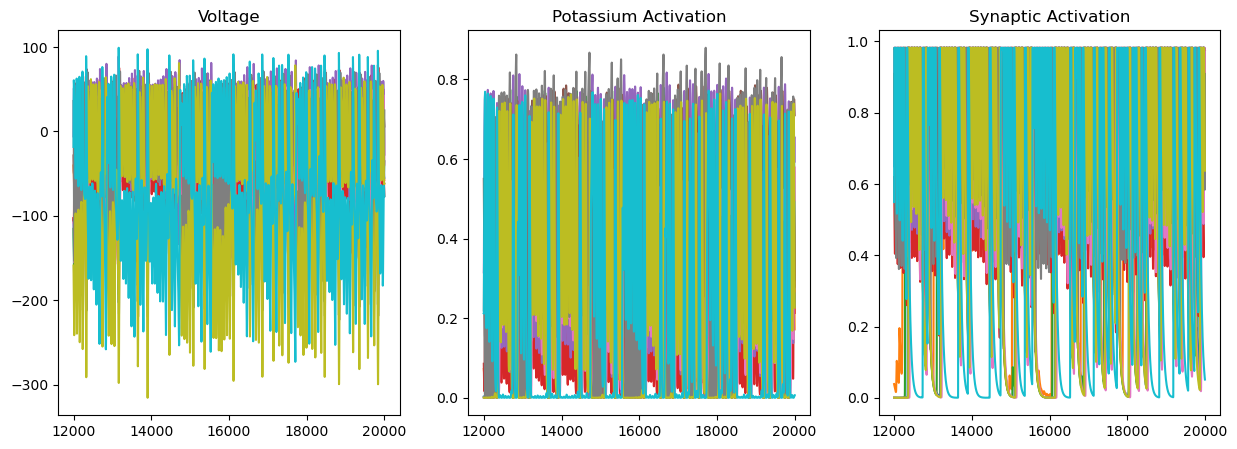

In [232]:
t_test = np.arange(nt_test) * dt + T - test_time

fig, ax = plt.subplots(1, 3, figsize=(15, 5), sharex=True)
ax[0].plot(t_test, v_rec_test.cpu().numpy())
ax[0].set_title('Voltage')
ax[1].plot(t_test, n_rec_test.cpu().numpy())
ax[1].set_title('Potassium Activation')
ax[2].plot(t_test, s_rec_test.cpu().numpy())
ax[2].set_title('Synaptic Activation')

plt.show()

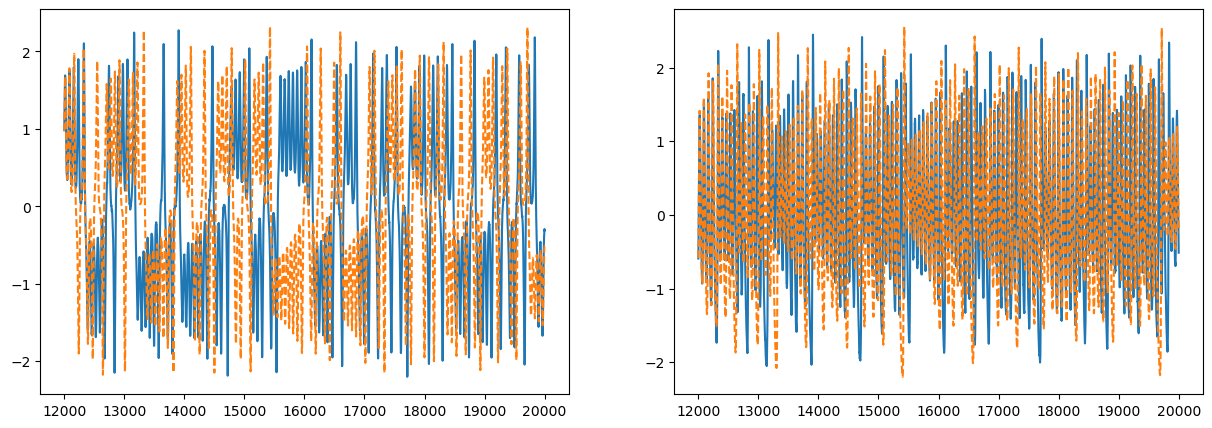

In [233]:
fig, ax = plt.subplots(1, 2, figsize=(15, 5), sharex=True)
ax[0].plot(t_test, x_hat_rec[:, 0].cpu().numpy())
ax[0].plot(t_test, sup[nt_train+2:, 0], '--')
ax[1].plot(t_test, x_hat_rec[:, 2].cpu().numpy())
ax[1].plot(t_test, sup[nt_train+2:, 2], '--')
plt.show()

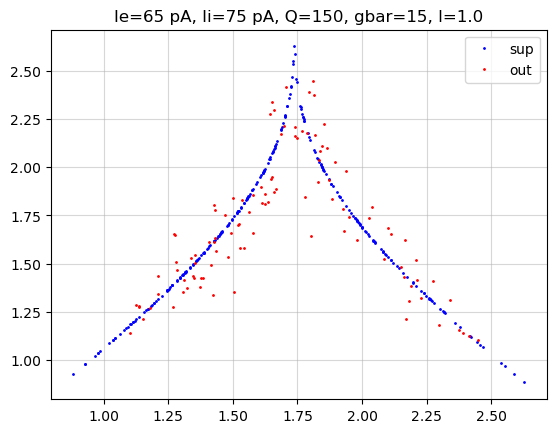

In [262]:

from scipy.signal import find_peaks

z = ml.sup[:, 2].cpu().numpy()
z_hat = x_hat_rec[:, 2].cpu().numpy()

dist = 1200

peaks = z[find_peaks(z, distance=dist)[0]]
# peaks = peaks[peaks > 0]
peaks_hat = z_hat[find_peaks(z_hat, distance=dist)[0]]
# peaks_hat = peaks_hat[peaks_hat > 0]

plt.plot(peaks[:-1], peaks[1:], 'bo', ms=1, label="sup")
plt.plot(peaks_hat[:-1], peaks_hat[1:], 'ro', ms=1, label="out")
# plt.xlim(0.5, 3)
# plt.ylim(0.5, 3)
plt.grid(alpha=.5)
plt.legend()
plt.title(f"Ie={Ie} pA, Ii={Ii} pA, Q={Q}, gbar={gbar}, l={lamda}")
plt.savefig(os.path.join(save_path, f"N_{ml._N}_ff_{ff_coeff}_return_map_.png"), dpi=300, bbox_inches='tight')
plt.show()

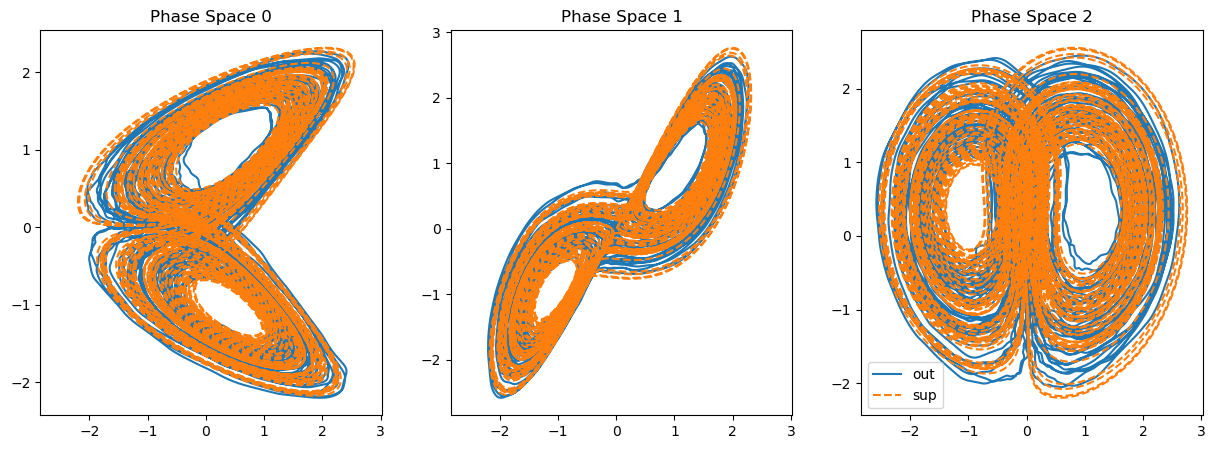

In [235]:
fig, ax = plt.subplots(ncols=ml.sup.shape[1], nrows=1, figsize=(15, 5), sharex=True)
for i in range(ml.sup.shape[1]):
    ax[i].plot(x_hat_rec[:, i-1].cpu().numpy(), x_hat_rec[:, i].cpu().numpy(), label="out")
    ax[i].plot(sup[nt_train+2:, i-1], sup[nt_train+2:, i], '--', label="sup")
    ax[i].set_title(f"Phase Space {i}")

plt.legend()
plt.savefig(os.path.join(save_path, f"N_{ml._N}_ff_{ff_coeff}_phase_space.png"), dpi=300, bbox_inches='tight')
plt.show()

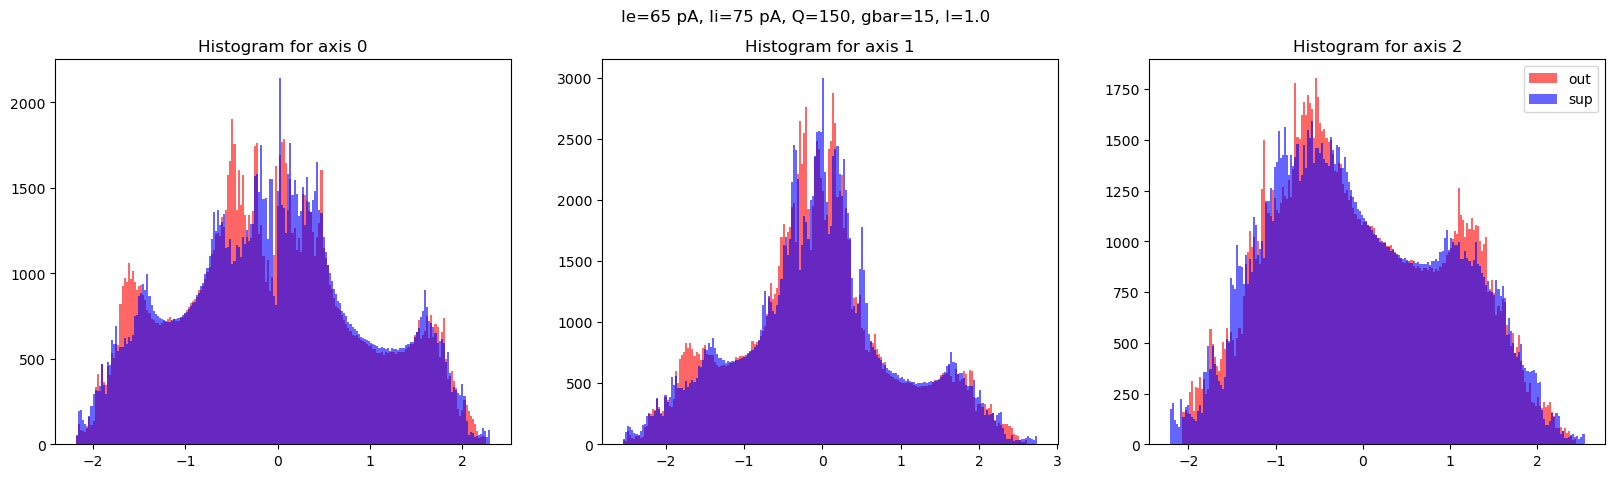

In [258]:
fig, ax = plt.subplots(figsize=(20, 5), ncols=3)

hists = []
for axis in range(len(ax)):
    sup_hist, bins = np.histogram(ml.sup[nt_train:, axis].cpu().numpy(), bins=200)
    output_hist, bins = np.histogram(x_hat_rec[:, axis].cpu().numpy(), bins=bins)
    hists.append((sup_hist, output_hist, bins))

    width = bins[1] - bins[0]
    alpha = .6
    ax[axis].bar(bins[:-1], output_hist, width=width, label="out", color='r', alpha=alpha)
    ax[axis].bar(bins[:-1], sup_hist, width=width, label="sup", color='b', alpha=alpha)
    ax[axis].set_title(f"Histogram for axis {axis}")
plt.suptitle(f"Ie={Ie} pA, Ii={Ii} pA, Q={Q}, gbar={gbar}, l={lamda}")
plt.legend()
plt.savefig(os.path.join(save_path, f"N_{ml._N}_ff_{ff_coeff}_histogram.png"), dpi=300, bbox_inches='tight')
plt.show()
